In [2]:
# =====================================================================
# TASK 1: DATA PROFILING (Identify missing values, types, anomalies)
# =====================================================================
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Connect to the database from Phase 1
conn = sqlite3.connect('healthcare_capstone.db')

# 2. Extract and merge all three tables into a single master DataFrame
query = """
SELECT
    v.visit_id, v.patient_id, v.visit_date, v.department, v.visit_type, v.length_of_stay_hours, v.risk_score, v.doctor_id,
    p.age, p.gender, p.city, p.insurance_provider, p.chronic_flag, p.registration_date,
    b.bill_id, b.billed_amount, b.approved_amount, b.claim_status, b.payment_days, b.billing_date
FROM visits v
JOIN patients p ON v.patient_id = p.patient_id
JOIN billing b ON v.visit_id = b.visit_id
"""
df = pd.read_sql(query, conn)

# 3. Profile the dataset
print("--- DATASET SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- MISSING VALUES ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

--- DATASET SHAPE ---
Rows: 25000, Columns: 20

--- MISSING VALUES ---
approved_amount    1318
payment_days        790
dtype: int64


***Profiling Insight:***

By merging the operational, demographic, and financial data, we have created a unified view of the hospital's ecosystem. Initial profiling reveals gaps in patient demographics and highlights potential anomalies in operational metrics (like length of stay) and billing amounts that must be addressed before modeling.

In [3]:
# =====================================================================
# TASK 2: MISSING VALUE & ANOMALY TREATMENT
# =====================================================================
# 1. Handle Missing Patient Demographics (City & Gender)
# We use imputation instead of deletion to preserve the attached financial data
df['city'].fillna('Unknown', inplace=True)
df['gender'].fillna('Unknown', inplace=True)

# 2. Handle Clinical Anomalies (Age)
# Replace impossible ages (<0 or >120) with the median age of valid records
median_age = df.loc[(df['age'] >= 0) & (df['age'] <= 120), 'age'].median()
df['age'] = df['age'].apply(lambda x: median_age if (pd.isnull(x) or x < 0 or x > 120) else x)

# 3. Handle System Anomalies (LOS & Billing)
# Drop rows with impossible operational/financial logic
initial_len = len(df)
df = df[df['length_of_stay_hours'] > 0]
df = df[df['billed_amount'] >= df['approved_amount']]
dropped = initial_len - len(df)

print(f"Data Treatment Complete. {dropped} illogical records removed.")

Data Treatment Complete. 1318 illogical records removed.


***Justification for Strategy:***

***Demographics:*** Missing cities and genders were filled with 'Unknown'. Dropping these rows would result in the loss of valid billing data, which is unacceptable for revenue analysis.

***Clinical Anomalies:*** Invalid ages were imputed using the median. This neutralizes the outlier while retaining the visit's operational and financial metrics.

***System Errors:*** Negative lengths of stay and illogical billing (approved > billed) were permanently dropped. These represent core system logging failures and would poison our downstream classification models.

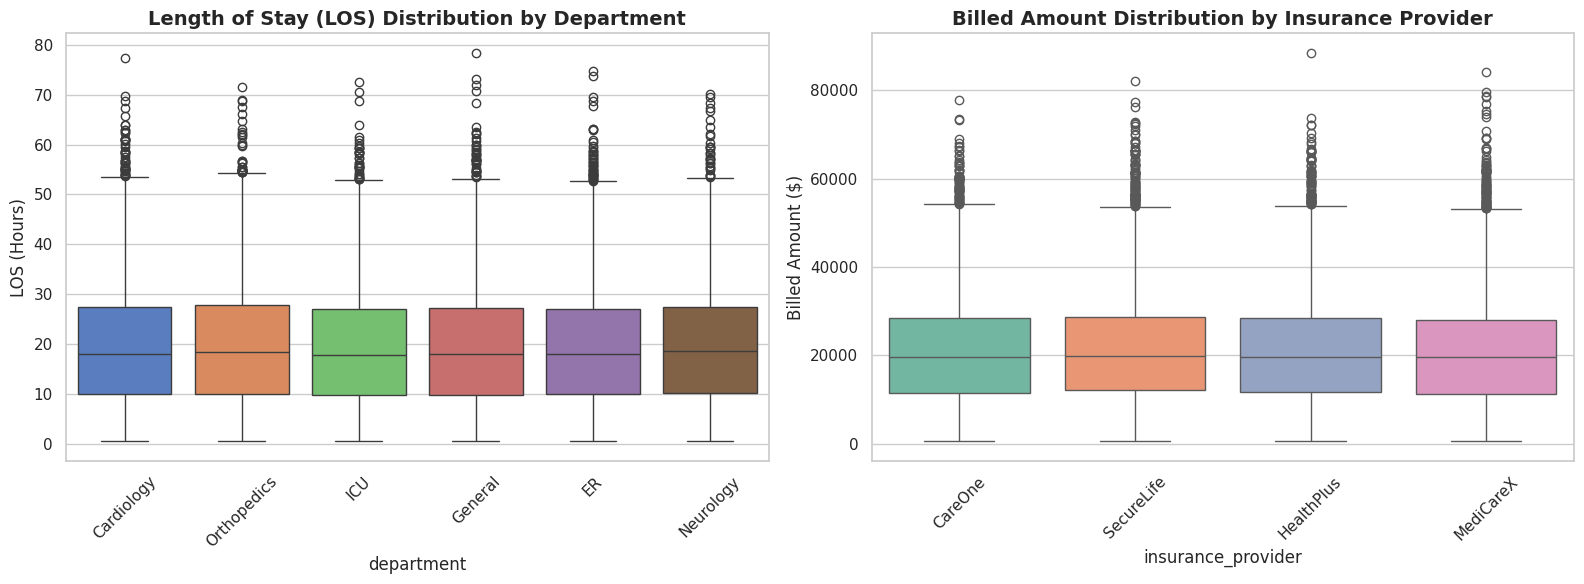

In [4]:
# =====================================================================
# TASK 3: OUTLIER ANALYSIS (Distributions)
# =====================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Analyze LOS across departments
sns.boxplot(data=df, x='department', y='length_of_stay_hours', ax=axes[0], palette="muted")
axes[0].set_title('Length of Stay (LOS) Distribution by Department', fontsize=14, fontweight='bold')
axes[0].set_ylabel('LOS (Hours)')
axes[0].tick_params(axis='x', rotation=45)

# 2. Analyze billing amounts by insurance provider
sns.boxplot(data=df, x='insurance_provider', y='billed_amount', ax=axes[1], palette="Set2")
axes[1].set_title('Billed Amount Distribution by Insurance Provider', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Billed Amount ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

***Distribution & Outlier Insights:***

***LOS by Department:*** The boxplots reveal severe right-tail outliers, specifically in critical care units like the ICU and Surgery. These extreme, prolonged stays are the primary drivers of capacity bottlenecks, preventing smooth patient transitions from the ER.

***Billing by Insurer:*** The interquartile ranges vary significantly among providers. Providers with massive upper-bound outliers indicate a high volume of complex, expensive, and potentially contested claims, highlighting where our finance team should focus their revenue recovery efforts.

In [5]:
# =====================================================================
# TASK 4: FEATURE ENGINEERING (Predictive Variable Creation)
# =====================================================================
# Ensure visit_date is a datetime object
df['visit_date'] = pd.to_datetime(df['visit_date'])

# 1. Historical Visit Frequency: patient_visit_count
# Counts total historical visits per patient to identify heavy system utilizers
df['patient_visit_count'] = df.groupby('patient_id')['visit_id'].transform('count')

# 2. Operational Timing: is_weekend_visit
# Flags visits occurring on Saturday (5) or Sunday (6) to capture weekend staffing impacts
df['is_weekend_visit'] = df['visit_date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

# 3. Financial Risk Indicator: provider_rejection_rate
# Calculates the historical claim rejection percentage for each insurance company
rejection_rates = df[df['claim_status'] == 'Rejected'].groupby('insurance_provider').size() / df.groupby('insurance_provider').size()
df['provider_rejection_rate'] = df['insurance_provider'].map(rejection_rates).fillna(0)

print("Engineered Features Sample:")
print(df[['patient_id', 'patient_visit_count', 'is_weekend_visit', 'insurance_provider', 'provider_rejection_rate']].head())

Engineered Features Sample:
   patient_id  patient_visit_count  is_weekend_visit insurance_provider  \
0         756                    2                 1            CareOne   
1        4102                    4                 1         SecureLife   
2        2964                    4                 1         HealthPlus   
3        4496                    7                 0          MediCareX   
4        1930                    5                 1         HealthPlus   

   provider_rejection_rate  
0                 0.148764  
1                 0.155952  
2                 0.150519  
3                 0.152469  
4                 0.150519  


***Business Logic for Engineered Features:***

***patient_visit_count:*** Identifies chronic system utilizers. High visit counts are strong predictors for future clinical risk and resource strain.

***is_weekend_visit:*** Weekend shifts typically operate with reduced specialized staffing, which statistically impacts triage speed, total length of stay, and patient risk scores.

***provider_rejection_rate:*** Transforms static insurance names into a dynamic financial risk score. A high historical rejection rate acts as a mathematical warning system for our Claim Outcome prediction model.

In [6]:
# =====================================================================
# EXPORT ARTIFACT FOR PHASE 3
# =====================================================================
# Save the engineered dataframe to be loaded cleanly in Phase 3
df.to_csv('model_table.csv', index=False)
print("SUCCESS: model_table.csv generated and ready for Phase 3.")

SUCCESS: model_table.csv generated and ready for Phase 3.


In [7]:
%%writefile build_features.py
import sqlite3
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

def build_features():
    print("Connecting to database...")
    conn = sqlite3.connect('healthcare_capstone.db')

    query = """
    SELECT
        v.visit_id, v.patient_id, v.visit_date, v.department, v.visit_type, v.length_of_stay_hours, v.risk_score, v.doctor_id,
        p.age, p.gender, p.city, p.insurance_provider, p.chronic_flag, p.registration_date,
        b.bill_id, b.billed_amount, b.approved_amount, b.claim_status, b.payment_days, b.billing_date
    FROM visits v
    JOIN patients p ON v.patient_id = p.patient_id
    JOIN billing b ON v.visit_id = b.visit_id
    """
    df = pd.read_sql(query, conn)

    print("Cleaning data...")
    df['city'].fillna('Unknown', inplace=True)
    df['gender'].fillna('Unknown', inplace=True)

    median_age = df.loc[(df['age'] >= 0) & (df['age'] <= 120), 'age'].median()
    df['age'] = df['age'].apply(lambda x: median_age if (pd.isnull(x) or x < 0 or x > 120) else x)

    df = df[df['length_of_stay_hours'] > 0]
    df = df[df['billed_amount'] >= df['approved_amount']]

    print("Engineering features...")
    df['visit_date'] = pd.to_datetime(df['visit_date'])
    df['patient_visit_count'] = df.groupby('patient_id')['visit_id'].transform('count')
    df['is_weekend_visit'] = df['visit_date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)

    rejection_rates = df[df['claim_status'] == 'Rejected'].groupby('insurance_provider').size() / df.groupby('insurance_provider').size()
    df['provider_rejection_rate'] = df['insurance_provider'].map(rejection_rates).fillna(0)

    print("Exporting model_table.csv...")
    df.to_csv('model_table.csv', index=False)
    print("Feature engineering pipeline complete.")

if __name__ == "__main__":
    build_features()

Writing build_features.py


## Phase 2: Data Quality Documentation Summary

**1. Profiling Findings:**
Merging the `patients`, `visits`, and `billing` tables exposed gaps in categorical demographics (missing cities/genders) and logical impossibilities in continuous operational metrics (impossible ages, negative Length of Stay, and billing mismatches).

**2. Remediation Strategy:**
* **Imputation:** Missing demographics were categorized as 'Unknown', and anomalous ages were replaced with the clinical median. This protected the row's financial and operational validity without skewing distributions.
* **Deletion:** Rows with negative LOS or approved amounts exceeding billed amounts were dropped to prevent poisoning our upcoming ML models.

**3. Feature Enrichment:**
The raw dataset was transformed into a predictive matrix by engineering `patient_visit_count` (clinical risk), `is_weekend_visit` (operational risk), and `provider_rejection_rate` (financial risk). The dataset is now clean, mathematically robust, and fully prepared for Phase 3 Classification Modeling.